## EXPERIMENT 4: Image Classification using Neural Network with R + Keras 3

### 1. Install Packages

In [2]:
install.packages(c("jpeg", "keras3"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### 2. Load Packages

In [3]:
library(jpeg)
library(keras3)

### 3. Read Images

In [4]:
# In Google Colab, upload your images to:
# /content/images

setwd("/content/sample_data/images")

pics <- c(
  "p1.jpg", "p2.jpg", "p3.jpg",
  "p4.jpg", "p5.jpg", "p6.jpg",
  "c1.jpg", "c2.jpg", "c3.jpg",
  "c4.jpg", "c5.jpg", "c6.jpg"
)

mypic <- list()

for (i in 1:12) {
  mypic[[i]] <- readJPEG(pics[i])
}

### 4. Explore Images

, , 1

             [,1]      [,2]      [,3]      [,4]      [,5]      [,6]      [,7]
   [1,] 0.9372549 0.9372549 0.9411765 0.9450980 0.9450980 0.9450980 0.9411765
   [2,] 0.9411765 0.9450980 0.9490196 0.9490196 0.9529412 0.9490196 0.9490196
   [3,] 0.9490196 0.9529412 0.9568627 0.9568627 0.9607843 0.9568627 0.9568627
   [4,] 0.9529412 0.9529412 0.9568627 0.9607843 0.9607843 0.9607843 0.9568627
   [5,] 0.9490196 0.9490196 0.9529412 0.9568627 0.9568627 0.9568627 0.9568627
   [6,] 0.9450980 0.9490196 0.9490196 0.9529412 0.9529412 0.9529412 0.9529412
   [7,] 0.9490196 0.9490196 0.9529412 0.9529412 0.9568627 0.9568627 0.9529412
   [8,] 0.9490196 0.9529412 0.9529412 0.9568627 0.9568627 0.9568627 0.9568627
   [9,] 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627
  [10,] 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627
  [11,] 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627
  [12,] 0.9568627 0.9568627 0.9568627 0.9568627 0.9568627

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.5373  0.6392  0.6362  0.7333  1.0000 

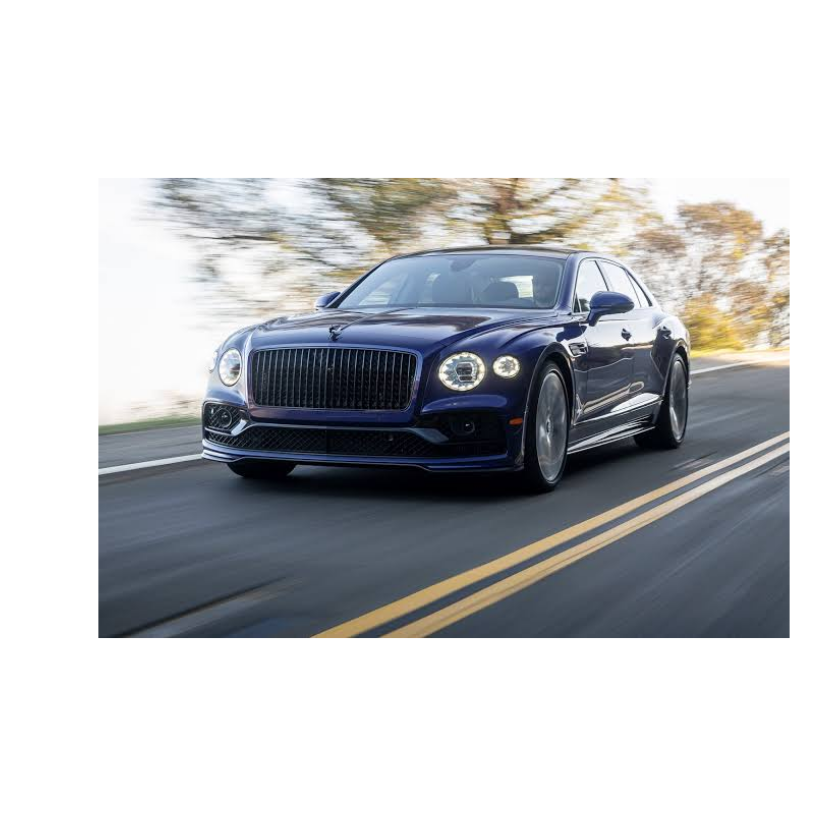

List of 12
 $ : num [1:3333, 1:5000, 1:3] 0.937 0.941 0.949 0.953 0.949 ...
 $ : num [1:681, 1:1222, 1:3] 0.435 0.435 0.435 0.435 0.435 ...
 $ : num [1:467, 1:700, 1:3] 0.796 0.796 0.796 0.796 0.8 ...
 $ : num [1:800, 1:1200, 1:3] 0.365 0.365 0.365 0.365 0.365 ...
 $ : num [1:432, 1:768, 1:3] 0.561 0.561 0.561 0.561 0.557 ...
 $ : num [1:466, 1:700, 1:3] 0.408 0.412 0.416 0.416 0.412 ...
 $ : num [1:426, 1:720, 1:3] 0.365 0.259 0.349 0.361 0.388 ...
 $ : num [1:452, 1:679, 1:3] 0.973 0.973 0.973 0.973 0.973 ...
 $ : num [1:365, 1:547, 1:3] 0.475 0.475 0.475 0.478 0.478 ...
 $ : num [1:480, 1:640, 1:3] 0.816 0.816 0.816 0.82 0.82 ...
 $ : num [1:433, 1:461, 1:3] 0.1569 0.4157 0.4157 0.3529 0.0471 ...
 $ : num [1:433, 1:709, 1:3] 0.824 0.824 0.824 0.827 0.827 ...


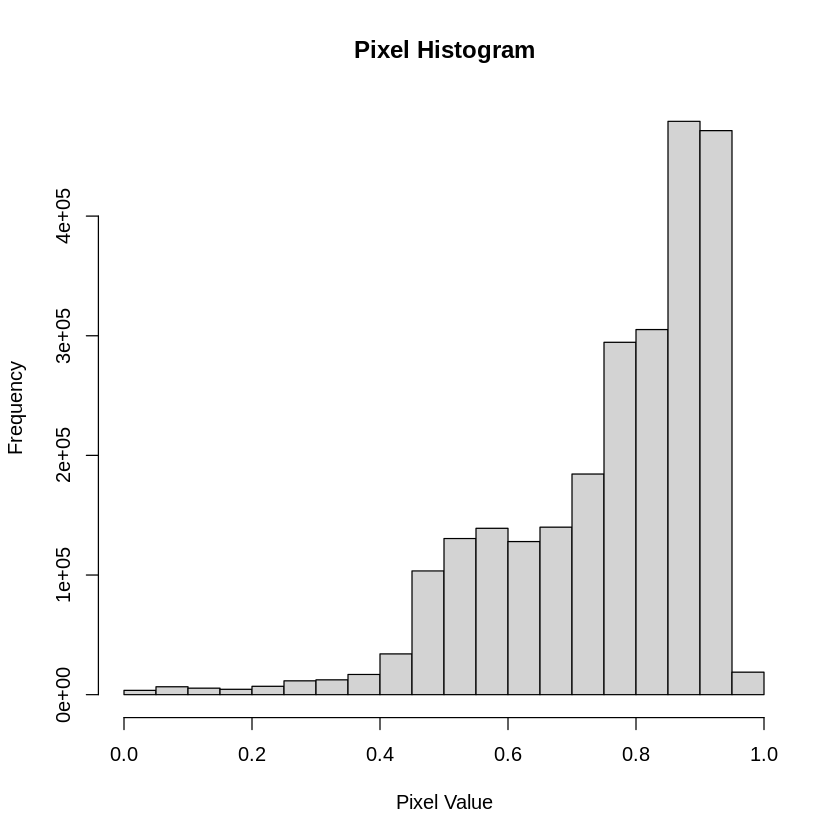

In [5]:
print(mypic[[1]])

# Display image
plot(
  as.raster(mypic[[8]]),
  main = "Image 8"
)

# Summary
summary(mypic[[1]])

# Histogram
hist(
  as.numeric(mypic[[2]]),
  main = "Pixel Histogram",
  xlab = "Pixel Value"
)

# Structure
str(mypic)

### 5. Resize Images to 28 x 28

In [6]:
# Simple nearest-neighbor resize using base R

resize_image <- function(img, width = 28, height = 28) {

  old_height <- dim(img)[1]
  old_width  <- dim(img)[2]

  row_index <- round(
    seq(1, old_height, length.out = height)
  )

  col_index <- round(
    seq(1, old_width, length.out = width)
  )

  row_index[row_index < 1] <- 1
  col_index[col_index < 1] <- 1

  resized <- img[row_index, col_index, , drop = FALSE]

  return(resized)
}


for (i in 1:12) {

  mypic[[i]] <- resize_image(
    mypic[[i]],
    28,
    28
  )

}


# Check dimensions

for (i in 1:12) {
  print(dim(mypic[[i]]))
}

[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3
[1] 28 28  3


### 6. Convert Images to Vectors

In [7]:
# 28 x 28 x 3 = 2352 features

image_to_vector <- function(img) {
  as.numeric(img)
}

### 7. Create Training Data

In [8]:
# Original experiment:
# images 7-11 = training
# images 6 and 12 = testing

trainx <- NULL

for (i in 7:11) {
  trainx <- rbind(
    trainx,
    image_to_vector(mypic[[i]])
  )
}

testx <- rbind(
  image_to_vector(mypic[[6]]),
  image_to_vector(mypic[[12]])
)

### 8. Create Labels

In [9]:
trainy <- c(
  0, 0, 0, 0, 0,
  1, 1, 1, 1, 1
)

testy <- c(
  0, 1
)

### Check Dimensions

In [10]:
print(dim(trainx))
print(dim(testx))

print(trainy)
print(testy)

[1]    5 2352
[1]    2 2352
 [1] 0 0 0 0 0 1 1 1 1 1
[1] 0 1


### 9. One-Hot Encoding

In [11]:
# Avoid to_categorical()
# Use base R instead

trainLabels <- cbind(
  as.numeric(trainy == 0),
  as.numeric(trainy == 1)
)

testLabels <- cbind(
  as.numeric(testy == 0),
  as.numeric(testy == 1)
)

print(trainLabels)
print(testLabels)

      [,1] [,2]
 [1,]    1    0
 [2,]    1    0
 [3,]    1    0
 [4,]    1    0
 [5,]    1    0
 [6,]    0    1
 [7,]    0    1
 [8,]    0    1
 [9,]    0    1
[10,]    0    1
     [,1] [,2]
[1,]    1    0
[2,]    0    1


### 10. Build Neural Network

In [12]:
model <- keras_model_sequential(
  input_shape = c(2352)
) |>
  layer_dense(
    units = 256,
    activation = "relu"
  ) |>
  layer_dense(
    units = 128,
    activation = "relu"
  ) |>
  layer_dense(
    units = 2,
    activation = "softmax"
  )


# Display model

summary(model)

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                     │ (None, 256)              │       602,368 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 2)                │           258 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘
 Total params: 635,522 (2.42 MB)
 Trainable params: 635,522 (2.42 MB)
 Non-trainable params: 0 (0.00 B)


### 11. Compile Model

In [13]:
compile(
  model,

  optimizer = optimizer_adam(),

  loss = "categorical_crossentropy",

  metrics = c("accuracy")
)

### 12. Train Model

In [15]:
history <- fit(
  model,

  trainx,

  trainLabels,

  epochs = 30,

  batch_size = 2,

  validation_split = 0.2
)

### 13. Evaluate Model

In [16]:
results <- evaluate(
  model,

  testx,

  testLabels
)

print(results)

$accuracy
[1] 0.5

$loss
[1] 35.7912



### 14. Predict

In [17]:
prob <- predict(
  model,
  testx
)

print(prob)

     [,1]         [,2]
[1,]    1 2.760702e-28
[2,]    1 8.168829e-32


### 15. Convert Probability to Class

In [18]:
pred <- max.col(prob) - 1

print(pred)

[1] 0 0


### 16. Confusion Matrix

In [19]:
table(
  Predicted = pred,
  Actual = testy
)

         Actual
Predicted 0 1
        0 1 1

### 17. Final Results

In [20]:
results_table <- cbind(
  prob,
  Predicted = pred,
  Actual = testy
)

print(results_table)

                    Predicted Actual
[1,] 1 2.760702e-28         0      0
[2,] 1 8.168829e-32         0      1
